In [34]:
import numpy as np

def cross_validation(X, y, k, model):
    X_arr = np.array(X)
    y_arr = np.array(y)

    m = len(y_arr)
    indices = np.random.permutation(m)

    fold_size = m // k
    folds = []
    for i in range(k):
        start_idx = i * fold_size
        if i == k - 1:
            folds.append(indices[start_idx:])
        else: 
            folds.append(indices[start_idx : start_idx + fold_size])

    accuracy_scores = []

    for i in range(k):
        test_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])

        X_train, y_train = X_arr[train_idx], y_arr[train_idx]
        X_test, y_test = X_arr[test_idx], y_arr[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = np.mean(y_pred == y_test)
        accuracy_scores.append(acc)
    mean_accuracy = np.mean(accuracy_scores)
    print('Cross-Validation Accuracy:', round(mean_accuracy,4))
    return mean_accuracy, folds

In [35]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score

iris = load_iris()
X = iris.data
y = iris.target

clf = DecisionTreeClassifier(random_state=42)
np.random.seed(42)
custom_score, folds = cross_validation(X,y,k=5,model=clf)
custom_splits = []
for i in range(5):
    test_idx = folds[i]
    train_idx = np.hstack([folds[j] for j in range(5) if j != i])
    custom_splits.append((train_idx, test_idx))

sklearn_scores = cross_val_score(clf,X,y,cv=custom_splits)
sklearn_mean = np.mean(sklearn_scores)

print('Customer Function Accuracy:', round(custom_score,4))
print('Scikit-Learn Accuracy:', round(sklearn_mean,4))
print('Match Confirmed:', np.isclose(custom_score, sklearn_mean))

Cross-Validation Accuracy: 0.9533
Customer Function Accuracy: 0.9533
Scikit-Learn Accuracy: 0.9533
Match Confirmed: True


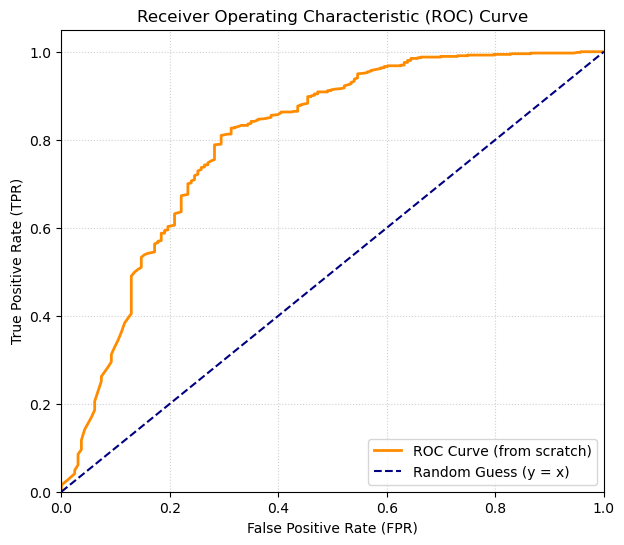

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
df = pd.read_csv('roc_curve_data.csv')
y_true = df['Actual_Label'].apply(lambda x: 1 if str(x).strip().upper() in ['1','Yes'] else 0).to_numpy()
y_prob = df['Pred_Prob_1'].to_numpy()

actual_positives = np.sum(y_true == 1)
actual_negatives = np.sum(y_true == 0)
cutoffs = np.arange(0.0,1.001,0.001)

tpr_list = []
fpr_list = []

for cutoff in cutoffs:
    preds = (y_prob >= cutoff).astype(int)
    tp = np.sum((y_true == 1) & (preds ==  1))
    fp = np.sum((y_true == 0) & (preds ==  1))
    tpr = tp / actual_positives if actual_positives > 0 else 0.0
    fpr = fp / actual_negatives if actual_negatives > 0 else 0.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr_list, tpr_list, color="darkorange", lw=2, label="ROC Curve (from scratch)")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Guess (y = x)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()